# Treinamento de Modelos: Classificação de Risco de Lesão no Futebol

Este notebook treina e avalia multíplos modelos de classificação usando validação cruzada.

**Objetivos:**
- Carregar features e rótulos pré processados
- Treinar modelos de Regressão Logística, Random Forest e SVM
- Executar validação cruzada estratificada (k=3)
- Comparar modelos com multíplas métricas (Accuracy, F1, Precision, Recall)
- Salvar o melhor modelo para inferência

In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent / "src"))
from train import InjuryRiskClassifier, load_processed_data

print("Imports concluídos")

Imports concluídos


## 1. Carregar Dados Processados

In [2]:
print("Carregando features e rótulos pré processados...")
data_dir = Path.cwd().parent
X, y = load_processed_data(data_dir)

print(f"Dados carregados com sucesso")
print(f"Matriz de features: {X.shape}")
print(f"Rótulos alvo: {y.shape}")
print(f"\nDistribuição do alvo:")
print(y.value_counts().sort_index())
print(f"\nAmostra de features:")
print(X.head())

Carregando features e rótulos pré processados...
Dados carregados com sucesso
Matriz de features: (28, 19)
Rótulos alvo: (28,)

Distribuição do alvo:
risk_label
0     5
1    16
2     7
Name: count, dtype: int64

Amostra de features:
   general_health  energy_level  sleep_hours  sleep_quality  wakes_rested  \
0       -1.083028     -0.338754     0.317999       1.154701      0.219382   
1        1.553909      1.016261     0.317999       1.154701      0.219382   
2        0.235441     -1.693769    -1.165998      -0.866025      0.219382   
3        0.235441     -0.338754     0.317999       1.154701      0.219382   
4        0.235441     -0.338754     0.317999       1.154701      0.219382   

   stress_level  motivation       rpe  fatigue_level  post_discomfort  \
0      0.159223         0.0 -0.274352       0.249619        -0.688247   
1     -1.326862         0.0 -0.274352       0.249619        -0.688247   
2      1.645309         0.0 -0.274352       0.715574         1.452966   
3     -1.326

## 2. Inicializar e Treinar Modelos

In [3]:
# Inicializa classificador com validação cruzada estratificada de 3 folds
clf = InjuryRiskClassifier(
    n_splits=3,
    random_state=42,
    models_dir=data_dir / "models"
)

print("Treinando modelos com Validação Cruzada Estratificada de 3 folds...\n")
results = clf.train_with_cv(X, y, verbose=True)

Treinando modelos com Validação Cruzada Estratificada de 3 folds...

Training: Logistic Regression

ACCURACY:
  Train: 1.0000 (+/- 0.0000)
  Test:  0.7148 (+/- 0.1365)

F1_WEIGHTED:
  Train: 1.0000 (+/- 0.0000)
  Test:  0.7075 (+/- 0.1446)

PRECISION_WEIGHTED:
  Train: 1.0000 (+/- 0.0000)
  Test:  0.7459 (+/- 0.1329)

RECALL_WEIGHTED:
  Train: 1.0000 (+/- 0.0000)
  Test:  0.7148 (+/- 0.1365)
Training: Random Forest

ACCURACY:
  Train: 1.0000 (+/- 0.0000)
  Test:  0.6407 (+/- 0.0618)

F1_WEIGHTED:
  Train: 1.0000 (+/- 0.0000)
  Test:  0.6266 (+/- 0.0732)

PRECISION_WEIGHTED:
  Train: 1.0000 (+/- 0.0000)
  Test:  0.6440 (+/- 0.0726)

RECALL_WEIGHTED:
  Train: 1.0000 (+/- 0.0000)
  Test:  0.6407 (+/- 0.0618)
Training: SVM

ACCURACY:
  Train: 0.8596 (+/- 0.1985)
  Test:  0.6444 (+/- 0.0960)

F1_WEIGHTED:
  Train: 0.8082 (+/- 0.2713)
  Test:  0.5369 (+/- 0.1179)

PRECISION_WEIGHTED:
  Train: 0.7784 (+/- 0.3134)
  Test:  0.4676 (+/- 0.1268)

RECALL_WEIGHTED:
  Train: 0.8596 (+/- 0.1985)
  Te

## 3. Comparação de Modelos - Resultados de Validação Cruzada

In [4]:
# Cria dataframe de resumo
summary_data = []
for model_name, cv_results in clf.results.items():
    metrics = {
        'Model': model_name,
        'Accuracy': f"{cv_results['test_accuracy'].mean():.4f} ± {cv_results['test_accuracy'].std():.4f}",
        'F1 (weighted)': f"{cv_results['test_f1_weighted'].mean():.4f} ± {cv_results['test_f1_weighted'].std():.4f}",
        'Precision': f"{cv_results['test_precision_weighted'].mean():.4f} ± {cv_results['test_precision_weighted'].std():.4f}",
        'Recall': f"{cv_results['test_recall_weighted'].mean():.4f} ± {cv_results['test_recall_weighted'].std():.4f}"
    }
    summary_data.append(metrics)

summary_df = pd.DataFrame(summary_data)
print("Resumo dos Resultados de Validação Cruzada")
print(summary_df.to_string(index=False))

Resumo dos Resultados de Validação Cruzada
              Model        Accuracy   F1 (weighted)       Precision          Recall
Logistic Regression 0.7148 ± 0.1365 0.7075 ± 0.1446 0.7459 ± 0.1329 0.7148 ± 0.1365
      Random Forest 0.6407 ± 0.0618 0.6266 ± 0.0732 0.6440 ± 0.0726 0.6407 ± 0.0618
                SVM 0.6444 ± 0.0960 0.5369 ± 0.1179 0.4676 ± 0.1268 0.6444 ± 0.0960


## 4. Identificar Melhor Modelo

In [5]:
best_name, best_model, best_score = clf.get_best_model(metric='f1_weighted')

print(f"\nMelhor modelo: {best_name}")
print(f"Melhor F1-Score: {best_score:.4f}")
print(f"\nDetalhes do modelo:")
print(best_model)


Melhor modelo: Logistic Regression
Melhor F1-Score: 0.7075

Detalhes do modelo:
LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)


## 5. Visualizar Métricas de Validação Cruzada

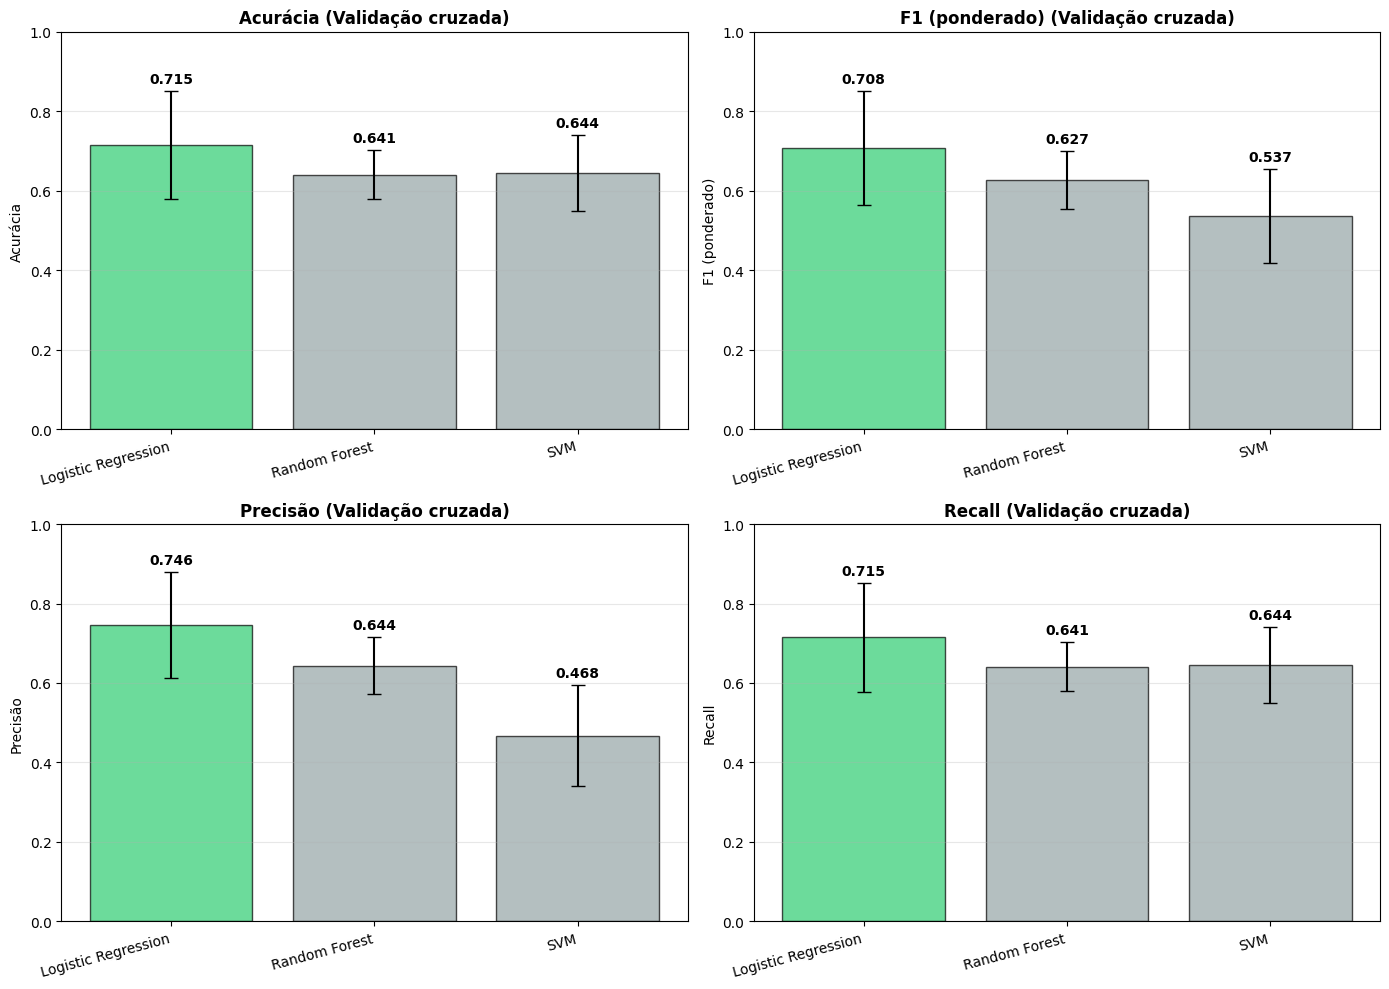

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics = ['accuracy', 'f1_weighted', 'precision_weighted', 'recall_weighted']
metric_labels = ['Acurácia', 'F1 (ponderado)', 'Precisão', 'Recall']

for idx, (metric, label) in enumerate(zip(metrics, metric_labels)):
    ax = axes[idx // 2, idx % 2]
    
    model_names = list(clf.results.keys())
    test_scores = [clf.results[name][f'test_{metric}'].mean() for name in model_names]
    test_stds = [clf.results[name][f'test_{metric}'].std() for name in model_names]
    
    x_pos = np.arange(len(model_names))
    colors = ['#2ecc71' if name == best_name else '#95a5a6' for name in model_names]
    
    ax.bar(x_pos, test_scores, yerr=test_stds, capsize=5, color=colors, alpha=0.7, edgecolor='black')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(model_names, rotation=15, ha='right')
    ax.set_ylabel(label)
    ax.set_title(f"{label} (Validação cruzada)", fontweight='bold')
    ax.set_ylim([0, 1])
    ax.grid(axis='y', alpha=0.3)
    
    # Adiciona rotulos de valor
    for i, (score, std) in enumerate(zip(test_scores, test_stds)):
        ax.text(i, score + std + 0.02, f"{score:.3f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Treinar Modelo Final no Dataset Completo

In [7]:
print(f"Treinando modelo final {best_name} no dataset completo...")
clf.train_final_model(X, y)
print(f"Modelo final treinado")

Treinando modelo final Logistic Regression no dataset completo...

Training final model: Logistic Regression
Dataset shape: (28, 19)
Modelo final treinado


## 7. Salvar Modelo e Resultados

In [8]:
from contextlib import redirect_stdout
import io

with redirect_stdout(io.StringIO()):
    model_path = clf.save_model("final_model.pkl")
    results_path = clf.save_results("training_results.json")

print("\nArtefatos salvos dentro do projeto:")
print(f"  - Modelo: {model_path.relative_to(data_dir).as_posix()}")
print(f"  - Resultados: {results_path.relative_to(data_dir).as_posix()}")


Artefatos salvos dentro do projeto:
  - Modelo: models/final_model.pkl
  - Resultados: models/training_results.json


## 8. Resumo do Treinamento

In [9]:
print("Resumo do Treinamento de Modelos")
print(f"\nDataset: {X.shape[0]} amostras, {X.shape[1]} features")
print(f"Validação cruzada: {clf.n_splits}-fold estratificada")
print(f"\nModelos treinados: 3")
print(f"  1. Logistic Regression (L2, balanced)")
print(f"  2. Random Forest (100 trees, max_depth=5, balanced)")
print(f"  3. SVM (RBF kernel, balanced)")
print(f"\nMelhor modelo: {best_name}")
print(f"Melhor F1-Score: {best_score:.4f}")
print(f"\nModelo salvo para a fase de inferência")

Resumo do Treinamento de Modelos

Dataset: 28 amostras, 19 features
Validação cruzada: 3-fold estratificada

Modelos treinados: 3
  1. Logistic Regression (L2, balanced)
  2. Random Forest (100 trees, max_depth=5, balanced)
  3. SVM (RBF kernel, balanced)

Melhor modelo: Logistic Regression
Melhor F1-Score: 0.7075

Modelo salvo para a fase de inferência
